In [6]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

region = "lytton"

# ---- Maeve ----
lon0, lon1 = 360 - 123, 360 - 118  # example: 235–245
lat0, lat1 = 48, 55

path_era = "/work/uc1275/u301827/02_MSE/full_midlatitude/era5_midlatitudes_JJA_compiled.nc"
path_txx = "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/txx_at_tasmax_merged_1940_2024.nc"

# =========================================================
# 1) ERA5 regional mean (for grey JJA background)
# =========================================================
ds0 = xr.open_dataset(path_era, chunks={"time": 200}, cache=False)

lon_slice = slice(lon0, lon1) if ds0.lon[0] < ds0.lon[-1] else slice(lon1, lon0)
lat_slice = slice(lat0, lat1) if ds0.lat[0] < ds0.lat[-1] else slice(lat1, lat0)

ds_box = ds0.sel(lon=lon_slice, lat=lat_slice)
ds_reg = ds_box.mean(dim=["lon", "lat"], skipna=True)

# squeeze common singleton dims if present
dims_to_remove = ["depth", "depth_2", "lev", "nhyi", "nhym"]
singleton_dims = [d for d in dims_to_remove if d in ds_reg.dims and ds_reg.sizes[d] == 1]
ds_reg = ds_reg.squeeze(singleton_dims, drop=True).compute()

In [7]:
# ---------------------------------------------------------
# Compute t_bound for ERA5 JJA regional-mean dataset ds_reg
# (same as your original code)
# ---------------------------------------------------------
R = 287.0       # J/kg/K
cp = 1004.0     # J/kg/K
p_ref = 500e2   # 500 hPa in Pa

ps  = ds_reg["sp_at_tasmax"]   # Pa  (surface pressure at tasmax time)
T500 = ds_reg["t_at_tasmax"]   # K   (500 hPa temperature at tasmax time)

# if T500 has a lev dimension, take the first level (like you did before)
if "lev" in T500.dims:
    T500 = T500.isel(lev=0)

ds_reg["t_bound"] = T500 * (ps / p_ref) ** (R / cp)

# now your background points work as-is
jja = ds_reg.sel(time=ds_reg.time.dt.month.isin([6, 7, 8]))
x_era = (jja["tasmax"] - 273.15).values.ravel()
y_era = (jja["t_bound"] - 273.15).values.ravel()
m = ~np.isnan(x_era) & ~np.isnan(y_era)
x_era, y_era = x_era[m], y_era[m]

# =========================================================
# 2) TXx-day dataset (already “composited”: one timestep per year)
# =========================================================
ds_txx0 = xr.open_dataset(path_txx)

# be robust to coord names
lon_name = "lon" if "lon" in ds_txx0.coords else ("longitude" if "longitude" in ds_txx0.coords else None)
lat_name = "lat" if "lat" in ds_txx0.coords else ("latitude"  if "latitude"  in ds_txx0.coords else None)
if lon_name is None or lat_name is None:
    raise ValueError(f"Could not find lon/lat coords in TXx file. Coords: {list(ds_txx0.coords)}")

lonv = ds_txx0[lon_name]
latv = ds_txx0[lat_name]
lon_slice_t = slice(lon0, lon1) if lonv[0] < lonv[-1] else slice(lon1, lon0)
lat_slice_t = slice(lat0, lat1) if latv[0] < latv[-1] else slice(lat1, lat0)

ds_txx_box = ds_txx0.sel({lon_name: lon_slice_t, lat_name: lat_slice_t})
ds_txx = ds_txx_box.mean(dim=[lon_name, lat_name], skipna=True)

# squeeze common singleton dims if present
singleton_dims = [d for d in dims_to_remove if d in ds_txx.dims and ds_txx.sizes[d] == 1]
ds_txx = ds_txx.squeeze(singleton_dims, drop=True).compute()


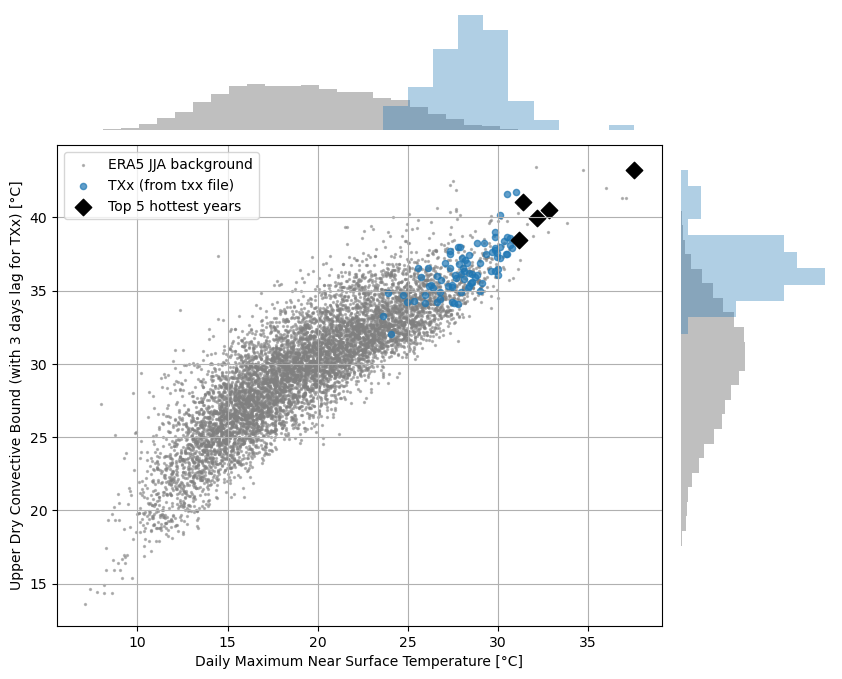

Saved: tasmax_tbound_lag_TXxday_lytton_from_txxfile.pdf


In [8]:
R = 287.0
cp = 1004.0
p_ref = 500e2  # 500 hPa in Pa

ps = ds_txx["sp_at_tasmax"]  # Pa
T500 = ds_txx["t500_premax_3d"] # K (should be 500 hPa temperature at tasmax-time)
ds_txx["t_bound"] = T500 * (ps / p_ref) ** (R / cp)

# =========================================================
# 3) Prepare TXx points (one per time entry; usually yearly)
# =========================================================
x = (ds_txx["tasmax"] - 273.15).values.ravel()
y = (ds_txx["t_bound"] - 273.15).values.ravel()
v = ~np.isnan(x) & ~np.isnan(y)
x, y = x[v], y[v]

# Top 5 hottest years (by tasmax on TXx day)
tas_series = (ds_txx["tasmax"] - 273.15).values
tas_series = tas_series.reshape(-1)  # 1D over time
top5_idx = np.argsort(tas_series)[-5:]

# =========================================================
# 4) Plot (same style as yours)
# =========================================================
plt.close("all")
fig = plt.figure(figsize=(10, 8))
gs = GridSpec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4], wspace=0.05, hspace=0.05)

ax_scatter = fig.add_subplot(gs[1, 0])
ax_histx   = fig.add_subplot(gs[0, 0], sharex=ax_scatter)
ax_histy   = fig.add_subplot(gs[1, 1], sharey=ax_scatter)

ax_scatter.scatter(x_era, y_era, c="grey", s=2, alpha=0.5, label="ERA5 JJA background")
ax_scatter.scatter(x, y, c="tab:blue", s=20, alpha=0.7, label="TXx (from txx file)")

# top 5 (use the *same* arrays before NaN filtering to keep indices consistent)
x_top = (ds_txx["tasmax"] - 273.15).values.reshape(-1)[top5_idx]
y_top = (ds_txx["t_bound"] - 273.15).values.reshape(-1)[top5_idx]
ax_scatter.scatter(x_top, y_top, c="black", edgecolor="black", s=70, marker="D", label="Top 5 hottest years")

ax_scatter.set_xlabel("Daily Maximum Near Surface Temperature [°C]")
ax_scatter.set_ylabel("Upper Dry Convective Bound (with 3 days lag for TXx) [°C]")
ax_scatter.grid(True)
ax_scatter.legend()

ax_histx.hist(x_era, bins=30, color="grey", alpha=0.5, density=True)
ax_histx.hist(x,     bins=10, color="tab:blue", alpha=0.35, density=True)
ax_histx.axis("off")

ax_histy.hist(y_era, bins=30, color="grey", alpha=0.5, density=True, orientation="horizontal")
ax_histy.hist(y,     bins=10, color="tab:blue", alpha=0.35, density=True, orientation="horizontal")
ax_histy.axis("off")

out = f"tasmax_tbound_lag_TXxday_{region}_from_txxfile.pdf"
fig.savefig(out, bbox_inches="tight")
plt.show()

print("Saved:", out)